# Cleaning a Lightcurve Using Quality Bitmasking
## Author
Aidan Niklaus

## Learning Goals
- Become familiar with Lightkurve basics
- Become familiar with quality bitmasking

## Keywords
Lightcurve, quality bitmasking
## Summary
This tutorial will demonstrate how to clean a lightcurve with a quality bitmask and the Python package Lightkurve.

## Imports

In [229]:
import lightkurve as lk
import matplotlib.pyplot as plt

# Makes plots appear directly after respective code block; functionally the same as "plt.show()"
%matplotlib inline

## Step 1: Implementing a Quality Bitmask
In the [previous tutorial](https://github.com/aidanniklaus/Summer-Research-2026/blob/main/Tutorials/FFI_LC_Decision_Tree_Tutorial.ipynb), the example lightcurve didn't need anymore cleaning, but what if yours does? The quickest way to do this is by asking Lightkurve to get rid of any datapoints it considers "bad" or suspicious, as often these points are the cause of funky looking graphs. This process uses a quality bitmask and is actually quite simple.

For this example, we wil use Sector 20 of the star TIC 156784035 as it has a very odd spike that not only dilutes the actual data we want to look at, but also reads negative flux, something we know is not possible.

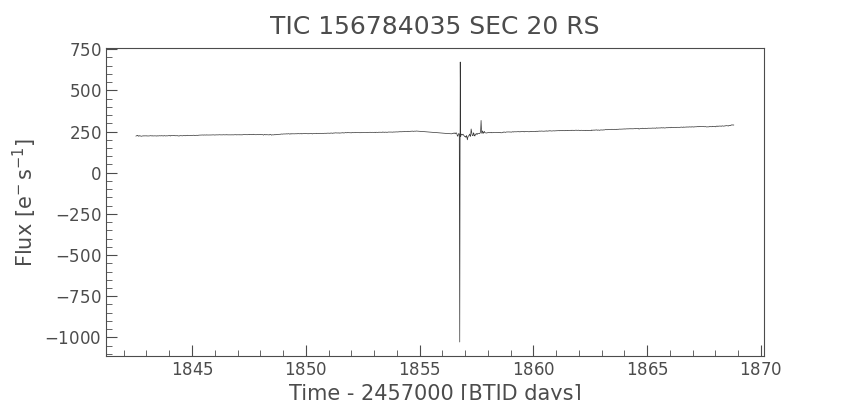

Let's start by searching for this star and sector combo.

In [226]:
# target : the name or identifying number of your star
# sector : sector number
search_result = lk.search_tesscut(target="TIC 156784035", sector=20)
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 20,2019,TESScut,1426,TIC 156784035,0.0


Now that we have found our data, we can apply the quality bitmask during download. There are a few different quality levels to choose from:
- 'none' : keeps all datapoints
- 'default' : removes most datapoints that suspiciously resemble noise
- 'hard' : slightly harsher, removes sudden spikes but may mistakingly remove flares because of this
- 'hardest' : uber strict, leaves only the "best" data

Note: your program will tell you if it thinks it's getting rid of too much data given the severity of your chosen quality level. This warning does not necessarily need to be heeded, but should definitely be considered as it may result in an equally as funky looking graph.

For our case, let's use 'hard' as we clearly have a massive spike that we know is not a flare.

In [227]:
# cutout_size : specifies the TPF "crop" size from the FFI; in this example, we asked for a 20x20 pixel TPF
# quality_bitmask : 'none', 'default', 'hard', or 'hardest', depending on quality desire
tpf = search_result[0].download(cutout_size=20, quality_bitmask='hard')

And that's it! Now that our TPF has the quality mask applied to it, we can do all the normal things we did in the [previous tutorial](https://github.com/aidanniklaus/Summer-Research-2026/blob/main/Tutorials/FFI_LC_Decision_Tree_Tutorial.ipynb). For convenience, I will include an abbreviated version of the code from said tutorial required to make our cleaned graph.

## Step 2: Regraphing our Lightcurve

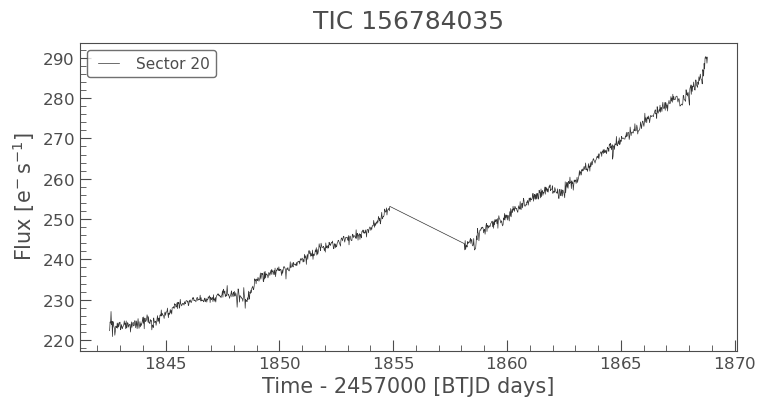

In [230]:
# Creating aperture mask of our target star
target_mask = tpf.create_threshold_mask(threshold=15, reference_pixel='center')

# Creating an initial lightcurve of our target star using our target mask
initial_lc = tpf.to_lightcurve(aperture_mask=target_mask)

# Creating aperture mask of the background (to capture inherent background noise that is not taken out by quality mask)
background_mask = ~tpf.create_threshold_mask(threshold=0.001, reference_pixel=None)

# Grabbing the amount of pixels in each of our masks to ultimately use to filter out average background noise
n_target_pixels = target_mask.sum()
n_background_pixels = background_mask.sum()

# Making an average noise per pixel lightcurve
background_lc_per_pixel = (tpf.to_lightcurve(aperture_mask=background_mask) / n_background_pixels)

# Multiplying our average noise per pixel lightcurve by the amount of pixels in our target mask to find a lightcurve representing the total noise present in our star pixels
noise_lc = background_lc_per_pixel * n_target_pixels

# Subtracting the total noise lightcurve from the original lightcurve to get our corrected lightcurve
corrected_lc = initial_lc - noise_lc

# Plotting our corrected light curve to see what we got! (Should be much different now that quality mask has been applied)
corrected_lc.plot(title="TIC 156784035", label="Sector 20");

# If you wish to save your figure locally:
    # For this example I am saving it to a folder called "Saved Graphs" within my current directory
filename = "TIC 156784035 Sector 20"
plt.savefig(f"Saved Graphs/{filename}")

## Step 3: Still Needs Cleaning?
No more negative flux spikes and we can actually see the data we want to see. That's great! This data is astrophysical and appears to be a long period star---we don't need to clean it anymore. However, it is possible that your data still is funky even after appying a quality bitmask. In this case, TESS-GAIA Light Curve (TGLC) is the way to go. Click [HERE](https://github.com/aidanniklaus/Summer-Research-2026/blob/main/Tutorials/TGLC_LC_Decision_Tree_Tutorial.ipynb) to continue to the TGLC tutorial ("Cleaning a Lightcurve Using TESS-GAIA Light Curve (TGLC)).

## Workflow Recap
Quality bitmasking is a simple and quick way to eliminate outlier data points that are visually messing up your lightcurves. Below is a recap of the workflow we used to do it:
1. search MAST for FFI(s) of our star
2. during download to TPF, apply a quality bitmask (may take a few tries to find one harsh enough to get rid of unwanted data, but not so harsh that it gets rid of necessary data)
3. regraph lightcurve and analyze for further cleaning (TGLC if yes)

## Bonus: What if We Had Used a Different Quality Level?
To demonstrate how different levels of checks impact the data, below are the resulting lightcurves for each of the four levels of quality masking.

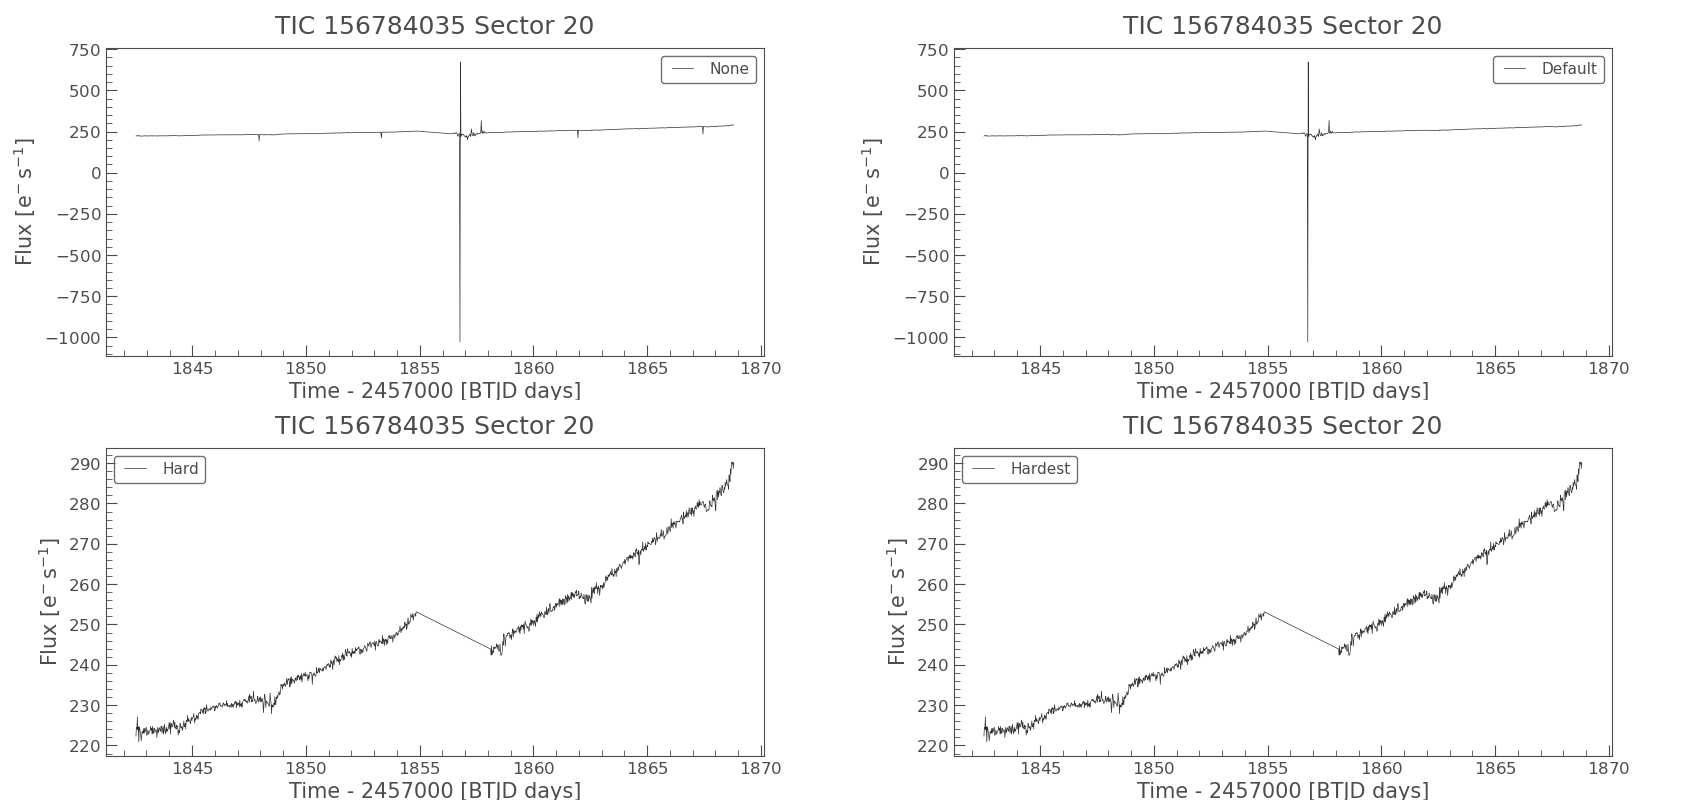
    
Looks like we were correct to choose a level greater than default, as otherwise the massive spike we were trying to eliminate would not have been handled. It is also noteworthy that we could have equally used "hard" or "hardest" to achieve our goal, but it is good practice to use the minimum harshness level required as overkill leaves you susceptible to unknowingly omitting data you wanted to keep.